# Exercises for Chapter 15, "Other generalized linear models"

In [2]:
import itertools
import os
import sys

import arviz
import bambi
import numpy
import pandas

from matplotlib import pyplot
from scipy import special

sys.path.append(os.path.abspath("/home/bgawalt/ros"))
import bg_ros

In [3]:
prng_builder = bg_ros.PRNGBuilder("""
    Chapter 15 here is kind of a crash course in all kinds of stuff you
    can learn about in future classes.  Early on, theres concrete focus
    on fitting some overdispersed distributions with the familiar
    stan_glm library, but later stuff (like Tobit regression, for
    censored data) is merely described and name-checked.
""")

## 15.1, Poisson and negative binomial regression

> The
> [folder `RiskyBehavior`](https://github.com/avehtari/ROS-Examples/tree/master/RiskyBehavior/)
> contains data from a randomized trial targeting couples at high risk of HIV
> infection. The intervention provided counseling sessions regarding practices
> that could reduce their likelihood of contracting HIV. Couples were randomized
> either to a control group, a group in which just the woman participated, or a
> group in which both members of the couple participated. One of the outcomes
> examined after three months was "number of unprotected sex acts."
> 
> (a) Model this outcome as a function of treatment assignment using a Poisson 
>     regression. Does the model fit well? Is there evidence of overdispersion?
> 
> (b) Next extend the model to include pre-treatment measures of the outcome and
>     the additional pre-treatment variables included in the dataset. Does the
>     model fit well? Is there evidence of overdispersion?
> 
> (c) Fit a negative binomial (overdispersed Poisson) model. What do you
>     conclude regarding effectiveness of the intervention?
> 
> (d) These data include responses from both men and women from the
>     participating couples. Does this give you any concern with regard to our
>     modeling assumptions?

In [4]:
rng = prng_builder.new('Exercise 15.1')

In [5]:
risky_df = pandas.read_csv('/home/bgawalt/ros/datasets/risky.csv')
print(bg_ros.dataframe_describe_markdown(risky_df))

|         | couples | women_alone | bupacts | fupacts
--------- | ------- | ----------- | ------- | -------
**count** | 434.00 | 434.00 | 434.00 | 434.00
**mean**  | 0.37 | 0.34 | 25.91 | 16.49
**std**   | 0.48 | 0.47 | 31.92 | 26.83
**min**   | 0.00 | 0.00 | 0.00 | 0.00
**25%**   | 0.00 | 0.00 | 5.00 | 0.00
**50%**   | 0.00 | 0.00 | 15.00 | 5.00
**75%**   | 1.00 | 1.00 | 36.00 | 20.93
**max**   | 1.00 | 1.00 | 300.00 | 200.00



In [6]:
risky_df.head()

,sex,couples,women_alone,bs_hiv,bupacts,fupacts
0,woman,0,1,negative,7,32.0
1,woman,0,0,negative,2,5.0
2,woman,0,0,positive,0,15.0
3,woman,0,0,negative,24,9.0
4,woman,1,0,negative,2,2.0


### 15.1(a)

In [7]:
risky1_model = bambi.Model(
    'fupacts ~ couples + women_alone',
    data=risky_df,
    family='poisson',
)
risky1_fit = risky1_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(risky1_fit, ['couples', 'women_alone']))

Initializing NUTS using jitter+adapt_diag...
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/link/c/cmodule.py:3004: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, couples, women_alone]


Output()

/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


Coef.       | Mean   | s.e.
----------- | ------ | ------
sigma       | nan | nan
Intercept   | 3.08 | 0.02
couples     | -0.32 | 0.03
women_alone | -0.57 | 0.03



In [8]:
risky1_preds = risky1_model.predict(risky1_fit, kind='response', inplace=False)
y_samples = []
for draw in rng.choice(1000, size=100):
    chain = rng.choice(4)
    y_samples.append(
        risky1_preds.posterior_predictive['fupacts'].sel(chain=chain, draw=draw).to_dataframe()['fupacts']
    )

In [9]:
act_hist, bin_edges = numpy.histogram(
    risky_df['fupacts'],
    bins=75, density=True)
bin_centers = [0.5 * (l + r) for l, r in itertools.pairwise(bin_edges)]
post_hists = [
    numpy.histogram(ys, bins=bin_edges, density=True)[0]
    for ys in y_samples
]

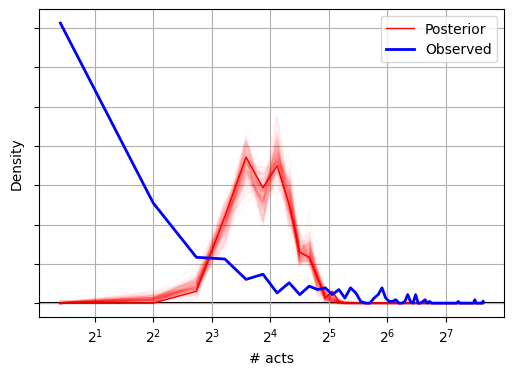

In [10]:
fig = pyplot.figure(figsize=(6, 4))
ax = fig.gca()
for i, ph in enumerate(post_hists):
    if i == 0:
        ax.semilogx(bin_centers, ph, color='r', linewidth=1, label='Posterior', base=2)
    else:
        ax.semilogx(bin_centers, ph, color='r', alpha=0.03, base=2)
ax.semilogx(bin_centers, act_hist, color='b', linewidth=2, label='Observed', base=2)
ax.set_xlabel('# acts')
ax.set_ylabel('Density')
ax.set_yticklabels([])
ax.grid()
ax.axhline(y=0, color='k', zorder=0)
ax.legend()

### 15.1(b)

In [11]:
risky2_model = bambi.Model(
    'fupacts ~ couples + women_alone + sex + bs_hiv + bupacts',
    data=risky_df,
    family='poisson',
)
risky2_fit = risky2_model.fit(idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, couples, women_alone, sex, bs_hiv, bupacts]


Output()

/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/tensor/blas.py:239: RuntimeWarning: invalid value encountered in dot
  out = np.dot(A, x)
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/tensor/blas.py:239: RuntimeWarning: invalid value encountered in dot
  out = np.dot(A, x)
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/tensor/blas.py:239: RuntimeWarning: invalid value encountered in dot
  out = np.dot(A, x)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


In [12]:
print(bg_ros.bambi_markdown(risky2_fit, ['couples', 'women_alone', 'sex[woman]', 'bs_hiv[positive]', 'bupacts']))

Coef.            | Mean   | s.e.
---------------- | ------ | ------
sigma            | nan | nan
Intercept        | 2.78 | 0.02
couples          | -0.41 | 0.03
women_alone      | -0.67 | 0.03
sex[woman]       | 0.11 | 0.02
bs_hiv[positive] | -0.44 | 0.04
bupacts          | 0.01 | 0.00



In [13]:
risky2_preds = risky2_model.predict(risky2_fit, kind='response', inplace=False)
y_samples = []
for draw in rng.choice(1000, size=100):
    chain = rng.choice(4)
    y_samples.append(
        risky2_preds.posterior_predictive['fupacts'].sel(chain=chain, draw=draw).to_dataframe()['fupacts']
    )

act_hist, bin_edges = numpy.histogram(
    risky_df['fupacts'],
    bins=75, density=True)
bin_centers = [0.5 * (l + r) for l, r in itertools.pairwise(bin_edges)]
post_hists = [
    numpy.histogram(ys, bins=bin_edges, density=True)[0]
    for ys in y_samples
]

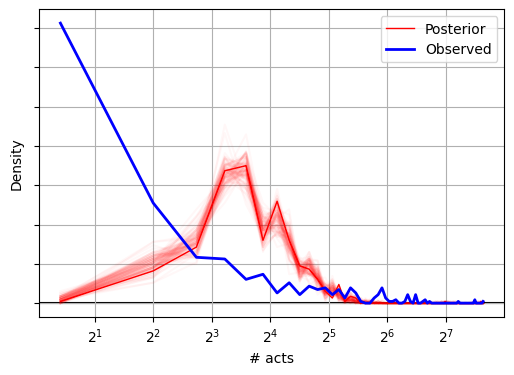

In [14]:
fig = pyplot.figure(figsize=(6, 4))
ax = fig.gca()
for i, ph in enumerate(post_hists):
    if i == 0:
        ax.semilogx(bin_centers, ph, color='r', linewidth=1, label='Posterior', base=2)
    else:
        ax.semilogx(bin_centers, ph, color='r', alpha=0.03, base=2)
ax.semilogx(bin_centers, act_hist, color='b', linewidth=2, label='Observed', base=2)
ax.set_xlabel('# acts')
ax.set_ylabel('Density')
ax.set_yticklabels([])
ax.grid()
ax.axhline(y=0, color='k', zorder=0)
ax.legend()

### 15.1(c)

In [15]:
risky3_model = bambi.Model(
    'fupacts ~ couples + women_alone + sex + bs_hiv + bupacts',
    data=risky_df,
    family='negativebinomial',
)
risky3_fit = risky3_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(risky3_fit, ['couples', 'women_alone', 'sex[woman]', 'bs_hiv[positive]', 'bupacts']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, couples, women_alone, sex, bs_hiv, bupacts]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


Coef.            | Mean   | s.e.
---------------- | ------ | ------
sigma            | nan | nan
Intercept        | 2.47 | 0.18
couples          | -0.34 | 0.20
women_alone      | -0.72 | 0.20
sex[woman]       | -0.03 | 0.15
bs_hiv[positive] | -0.55 | 0.19
bupacts          | 0.02 | 0.00



In [16]:
risky3_preds = risky3_model.predict(risky3_fit, kind='response', inplace=False)
y_samples = []
for draw in rng.choice(1000, size=100):
    chain = rng.choice(4)
    y_samples.append(
        risky3_preds.posterior_predictive['fupacts'].sel(chain=chain, draw=draw).to_dataframe()['fupacts']
    )

act_hist, bin_edges = numpy.histogram(
    risky_df['fupacts'],
    bins=75, density=True)
bin_centers = [0.5 * (l + r) for l, r in itertools.pairwise(bin_edges)]
post_hists = [
    numpy.histogram(ys, bins=bin_edges, density=True)[0]
    for ys in y_samples
]

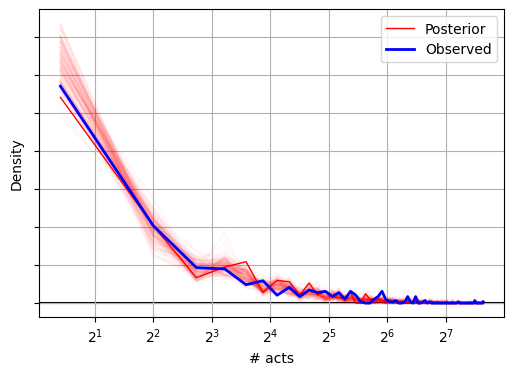

In [17]:
fig = pyplot.figure(figsize=(6, 4))
ax = fig.gca()
for i, ph in enumerate(post_hists):
    if i == 0:
        ax.semilogx(bin_centers, ph, color='r', linewidth=1, label='Posterior', base=2)
    else:
        ax.semilogx(bin_centers, ph, color='r', alpha=0.03, base=2)
ax.semilogx(bin_centers, act_hist, color='b', linewidth=2, label='Observed', base=2)
ax.set_xlabel('# acts')
ax.set_ylabel('Density')
ax.set_yticklabels([])
ax.grid()
ax.axhline(y=0, color='k', zorder=0)
ax.legend()

/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

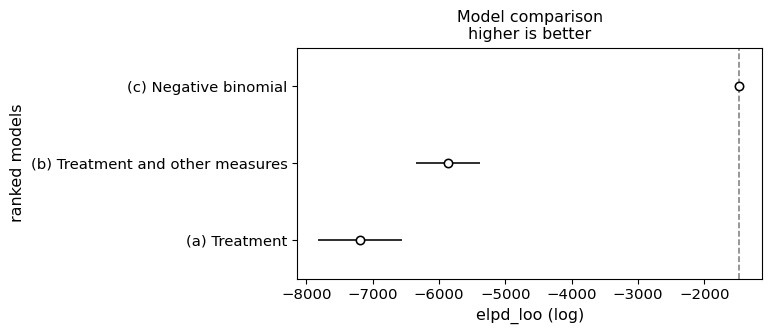

In [18]:
risky_models = {
    '(a) Treatment': risky1_fit,
    '(b) Treatment and other measures': risky2_fit,
    '(c) Negative binomial': risky3_fit,
}
risky_compare = arviz.compare(risky_models)
arviz.plot_compare(risky_compare)

## 15.3, Binomial regression

> Redo the basketball shooting example on page 270, making some changes:
> 
> (a) Instead of having each player shoot 20 times, let the number of shots per
>     player vary, drawn from the uniform distribution between 10 and 30.
> 
> (b) Instead of having the true probability of success be linear, have the true
>     probability be a logistic function, set so that $\text{Pr(success)} = 0.3$
>     for a player who is 5'9" and 0.4 for a 6' tall player.

In [19]:
rng = prng_builder.new('Exercise 15.3')

In [20]:
b = (special.logit(0.4) - special.logit(0.3)) / 3
a = special.logit(0.4) - 72 * b
print(f'a: {a:0.2f}')
print(f'b: {b:0.2f}')

a: -11.01
b: 0.15


In [21]:
num_players = 100
heights = rng.normal(loc=72, scale=3, size=num_players)
ps = special.expit(a + b * heights)
shots = rng.integers(low=10, high=30, endpoint=True, size=num_players)
hits = rng.binomial(shots, ps)
bball_df = pandas.DataFrame(data={'height': heights, 'shots': shots, 'hits': hits})

In [22]:
bball_model = bambi.Model('p(hits, shots) ~ height', bball_df, family='binomial')
bball_fit = bball_model.fit()
print(bg_ros.bambi_markdown(bball_fit, ['height'],))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, height]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | nan | nan
Intercept | -9.33 | 1.16
height    | 0.12 | 0.02



## 15.4, Multinomial logit

> Using the individual-level survey data from the 2000 National Election Study
> (data
> [in folder `NES`](https://github.com/avehtari/ROS-Examples/tree/master/NES/)),
> predict party identification (which is on a five-point scale) using ideology
> and demographics with an ordered multinomial logit model.
> 
> (a) Summarize the parameter estimates numerically and also graphically.
> 
> (b) Explain the results from the fitted model.
> 
> (c) Use a binned residual plot to assess the fit of the model.

In [23]:
nes_parser = bg_ros.DATFileParser('/home/bgawalt/ros/datasets/nes.txt')
nes_parser.add_int_filter('year', lambda y: y == 2000)
nes_df, nes_nas = nes_parser.parse(
    [
        "year", "income", "age", "gender",
        "race", "real_ideo", "martial_status", "partyid7"],
    [],
)
print(bg_ros.dataframe_describe_markdown(nes_df))

|         | year | income | age | gender | race | real_ideo | martial_status | partyid7
--------- | ---- | ------ | --- | ------ | ---- | --------- | -------------- | --------
**count** | 474.00 | 474.00 | 474.00 | 474.00 | 474.00 | 474.00 | 474.00 | 474.00
**mean**  | 2000.00 | 3.03 | 47.61 | 1.53 | 1.53 | 4.31 | 2.01 | 3.82
**std**   | 0.00 | 1.11 | 15.84 | 0.50 | 1.18 | 1.41 | 1.44 | 2.16
**min**   | 2000.00 | 1.00 | 18.00 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00
**25%**   | 2000.00 | 2.00 | 36.00 | 1.00 | 1.00 | 3.00 | 1.00 | 2.00
**50%**   | 2000.00 | 3.00 | 45.00 | 2.00 | 1.00 | 4.00 | 1.00 | 4.00
**75%**   | 2000.00 | 4.00 | 57.75 | 2.00 | 1.00 | 5.00 | 3.00 | 6.00
**max**   | 2000.00 | 5.00 | 91.00 | 2.00 | 5.00 | 7.00 | 7.00 | 7.00



In [24]:
nes_df['party_cat'] = pandas.Categorical(nes_df['partyid7'], ordered=True)
nes_model = bambi.Model(
    'party_cat ~ income + age + gender + real_ideo',
    nes_df,
    family='cumulative',
)
nes_fit = nes_model.fit()

/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/bambi/formula.py:111: UserWarning: The intercept is omitted in ordinal families
  warnings.warn("The intercept is omitted in ordinal families")
Initializing NUTS using jitter+adapt_diag...
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/compile/function/types.py:1038: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [threshold, income, age, gender, real_ideo]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.


In [25]:
arviz.summary(nes_fit)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
threshold[0],-0.387,0.338,-1.024,0.233,0.007,0.006,2486.0,2410.0,1.0
threshold[1],0.421,0.333,-0.227,1.024,0.006,0.005,2682.0,2462.0,1.0
threshold[2],1.175,0.334,0.527,1.799,0.006,0.005,3017.0,2597.0,1.0
threshold[3],1.518,0.339,0.895,2.182,0.006,0.005,3002.0,2646.0,1.0
threshold[4],2.280,0.347,1.606,2.910,0.006,0.005,3258.0,2744.0,1.0
threshold[5],3.320,0.357,2.634,3.962,0.006,0.005,3338.0,2822.0,1.0
income,0.092,0.070,-0.037,0.223,0.001,0.001,3531.0,2936.0,1.0
age,-0.020,0.005,-0.030,-0.011,0.000,0.000,3117.0,3140.0,1.0
gender,-0.579,0.144,-0.844,-0.304,0.002,0.002,3527.0,3171.0,1.0
real_ideo,0.651,0.063,0.537,0.771,0.001,0.001,3388.0,2992.0,1.0


In [26]:
print(bg_ros.bambi_markdown(
    nes_fit,
    [f'threshold[{i}]' for i in range(6)] + ['income', 'age', 'gender', 'real_ideo']
))        

Coef.        | Mean   | s.e.
------------ | ------ | ------
sigma        | nan | nan
Intercept    | nan | nan
threshold[0] | -0.39 | 0.34
threshold[1] | 0.42 | 0.33
threshold[2] | 1.18 | 0.33
threshold[3] | 1.52 | 0.34
threshold[4] | 2.28 | 0.35
threshold[5] | 3.32 | 0.36
income       | 0.09 | 0.07
age          | -0.02 | 0.01
gender       | -0.58 | 0.14
real_ideo    | 0.65 | 0.06



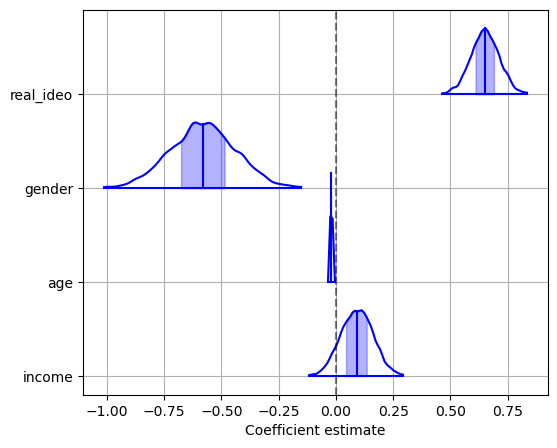

In [27]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
bg_ros.plot_ridge(ax, nes_fit, ['income', 'age', 'gender', 'real_ideo'])

In [28]:
nes_summ = arviz.summary(nes_fit)["mean"]
b_age = nes_summ['age']
b_income = nes_summ['income']
b_gender = nes_summ['gender']
b_ideo = nes_summ['real_ideo']

In [29]:
actual_to_preds = {}
for _, row in nes_df.iterrows():
    pred = (
        row['age'] * b_age +
        row['income'] * b_income +
        row['gender'] * b_gender +
        row['real_ideo'] * b_ideo
    )
    act = int(row['party_cat'])
    if act not in actual_to_preds:
        actual_to_preds[act] = []
    actual_to_preds[act].append(pred)
atp_list = [actual_to_preds[i] for i in sorted(actual_to_preds.keys())]

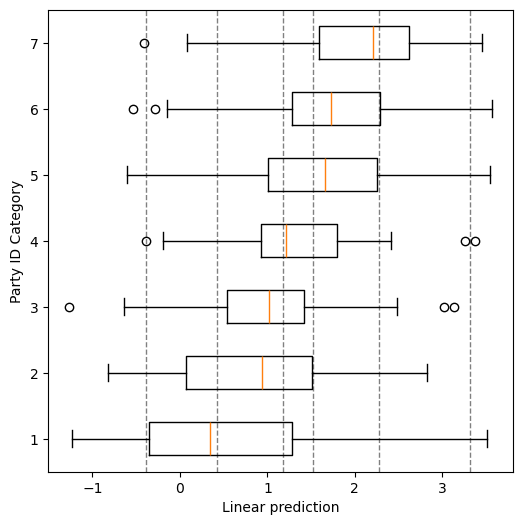

In [30]:
fig = pyplot.figure(figsize=(6, 6))
ax = fig.gca()
ax.boxplot(atp_list, orientation='horizontal')
ax.set_ylabel('Party ID Category')
ax.set_xlabel('Linear prediction')
for k in range(6):
    ax.axvline(nes_summ[f'threshold[{k}]'], color='grey', linewidth=1, linestyle='--', zorder=0)

## 15.5, Comparing logit and probit

> Take one of the data examples from Chapter 13 or 14. Fit these data using both
> logit and probit models. Check that the results are essentially the same after
> scaling by factor of 1.6 (see Figure 15.4).

In [34]:
wells_df = pandas.read_csv('/home/bgawalt/ros/datasets/wells.csv')
wells_df['log_arsenic'] = numpy.log(wells_df['arsenic'])
wells_formula = "switch['1'] ~ dist100 + log_arsenic + dist100:log_arsenic"

In [36]:
wells_logit_model = bambi.Model(
    wells_formula,
    data=wells_df,
    family='bernoulli',
    link='logit',
)
wells_logit_fit = wells_logit_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(wells_logit_fit, ["dist100", "log_arsenic", "dist100:log_arsenic"]))

Modeling the probability that switch==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dist100, log_arsenic, dist100:log_arsenic]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


Coef.               | Mean   | s.e.
------------------- | ------ | ------
sigma               | nan | nan
Intercept           | 0.49 | 0.07
dist100             | -0.88 | 0.13
log_arsenic         | 0.98 | 0.11
dist100:log_arsenic | -0.23 | 0.18



In [37]:
wells_probit_model = bambi.Model(
    wells_formula,
    data=wells_df,
    family='bernoulli',
    link='probit',
)
wells_probit_fit = wells_probit_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(wells_probit_fit, ["dist100", "log_arsenic", "dist100:log_arsenic"]))

Modeling the probability that switch==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dist100, log_arsenic, dist100:log_arsenic]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


Coef.               | Mean   | s.e.
------------------- | ------ | ------
sigma               | nan | nan
Intercept           | 0.30 | 0.04
dist100             | -0.54 | 0.08
log_arsenic         | 0.59 | 0.07
dist100:log_arsenic | -0.12 | 0.11



In [39]:
for lc, pc in zip([0.49, -0.88, 0.98, -0.23], [0.3, -0.54, 0.59, -0.12]):
    print(lc / pc)

1.6333333333333333
1.6296296296296295
1.6610169491525424
1.9166666666666667


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

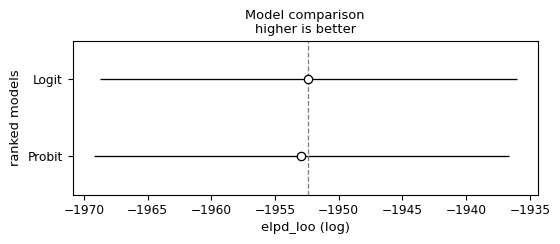

In [38]:
wells_models = {
    'Logit': wells_logit_fit,
    'Probit': wells_probit_fit,
}
wells_compare = arviz.compare(wells_models)
arviz.plot_compare(wells_compare)